# Assumptions

## What is an assumption anyways?

### Challenge: identifying assumptions

Take 5 minutes to list out as many assumptions as you can about the EIA 923 Puerto Rico data in the [data directory](../data/).

The goal is to get past the obvious ones and start thinking of some un-obvious assumptions - no need to limit yourself to 'realistic' ones at this stage.

In [154]:
import calendar

import pandas as pd

In [156]:
pr_gen_fuel = pd.read_csv("../data/pr_gen_fuel.csv", na_values=["."])
del pr_gen_fuel["Unnamed: 0"]

monthly_variables = {col.rsplit("_", 1)[0] for col in pr_gen_fuel.columns if col.endswith("january")}
id_variables = ["plant_id_eia", "plant_name_eia", "report_year", "energy_source_code", "prime_mover_code"]

month_names = [mn.lower() for mn in calendar.month_name if mn != ""]

monthlies = []
for var_name in monthly_variables:
    long = pr_gen_fuel.melt(
        id_vars=id_variables,
        value_vars=[f"{var_name}_{mn}" for mn in month_names],
        value_name=var_name,
        var_name="month"
    )
    long["month"] = long.month.str.extract(r"_([a-zA-Z]+)$")
    long["date"] = pd.to_datetime(long.month + long.report_year.astype(int).astype(str), format="%B%Y")
    monthlies.append(
        long.drop(columns=["report_year", "month"])
        .set_index(["date", "plant_id_eia", "plant_name_eia", "energy_source_code", "prime_mover_code"])
    )

monthly_gen_fuel = pd.concat(monthlies, axis=1).reset_index()

In [134]:
solar_pv_post_2022 = monthly_gen_fuel[
    (monthly_gen_fuel["date"] >= "2022-01-01") &
    (monthly_gen_fuel["energy_source_code"] == "SUN") &
    (monthly_gen_fuel["prime_mover_code"] == "PV")
]
consumption_btu = solar_pv_post_2022["fuel_consumed_for_electricity_mmbtu"] * 1_000_000
net_gen_kwh = solar_pv_post_2022["net_generation_mwh"] * 1_000
heat_rate = consumption_btu / net_gen_kwh


<Axes: >

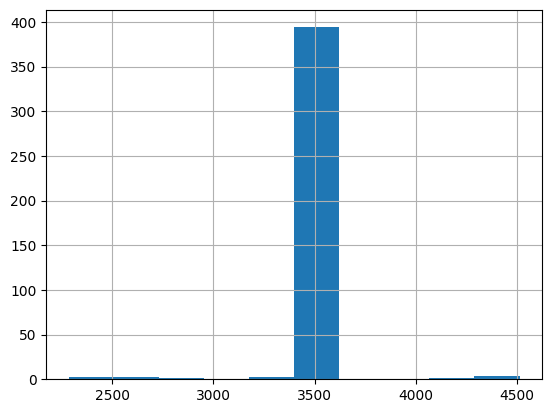

In [135]:
heat_rate.hist()

In [158]:
heat_rate.std() / heat_rate.mean()

np.float64(0.04581208344544627)